# M4 - Brief 1 - Benchmark de modèles d'IA pour une tâche de régression

**tl;dr** : prédire le prix médian des logements à Boston `medv`

## Sommaire

### Phase 1 — Nettoyage déterministe (avant split)
*Étapes qui ne dépendent pas de la distribution statistique des données. Aucun risque de data leakage.*

1. Imports et chargement
2. Analyse Exploratoire des Données (EDA)
3. Nettoyage éthique (virer `b`)
4. Nettoyage des colonnes quasi-vides (seuil 50%)
5. Règles métier
6. Bilan du nettoyage déterministe

### Split Train/Test (80/20) **AVANT** l'imputation (KNN) et outliers (IQR)
7. Split train/test

### Phase 2 — Preprocessing statistique (après split)
*Étapes qui dépendent distribution statistique des données. Risque de data leakage.*
8. Détection des outliers (IQR)
9. Suppression des 2% de lignes les plus incomplètes (après règles métier et IQR qui vont créer des NaN)
10. Standardisation
11. Imputation KNN

### Phase 3 — Modélisation et évaluation

12. Modélisation : Régression Linéaire, Random Forest, LightGBM
13. **Validation croisée (Cross-Validation 5-fold)**
14. Visualisations et **tableau récapitulatif RMSE / MAE / R²**
15. **Feature importance**
16. **Conclusion, limites et recommandations**

In [86]:
# Pour que python arrete de faire chie avec distutils
import setuptools
import sys

import pandas as pd
import numpy as np

In [87]:
df = pd.read_csv('./resources/boston-housing.csv')
print(f"Table size: {df.shape[0]} rows x {df.shape[1]} columns")

Table size: 506 rows x 14 columns


## 2. EDA

**EDA = Exploratory Data Analysis** = phase d'inspection avant tout traitement.
On veut comprendre :
- la **structure** du dataset (types, dimensions)
- la **qualité** des données (NaN, distributions, valeurs aberrantes)
- les **relations** entre variables (corrélations)

> Cette section est purement descriptive : on **ne modifie pas** encore le dataset.

### 2.1 Vue d'ensemble

In [88]:
# 5 premières lignes
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [89]:
# Types des colonnes et présence de valeurs nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [90]:
# Statistiques
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 2.2 Comptage des NaN

In [91]:
nan_par_colonne = df.isnull().sum().sort_values(ascending=False)
nan_pct = (nan_par_colonne / len(df) * 100).round(2)

resume_nan = pd.DataFrame({
    'NaN (count)': nan_par_colonne,
    'NaN (%)': nan_pct
})
print(resume_nan)
print(f"\nTotal NaN dans le dataset : {df.isnull().sum().sum()}")

         NaN (count)  NaN (%)
crim               0      0.0
zn                 0      0.0
indus              0      0.0
chas               0      0.0
nox                0      0.0
rm                 0      0.0
age                0      0.0
dis                0      0.0
rad                0      0.0
tax                0      0.0
ptratio            0      0.0
b                  0      0.0
lstat              0      0.0
medv               0      0.0

Total NaN dans le dataset : 0


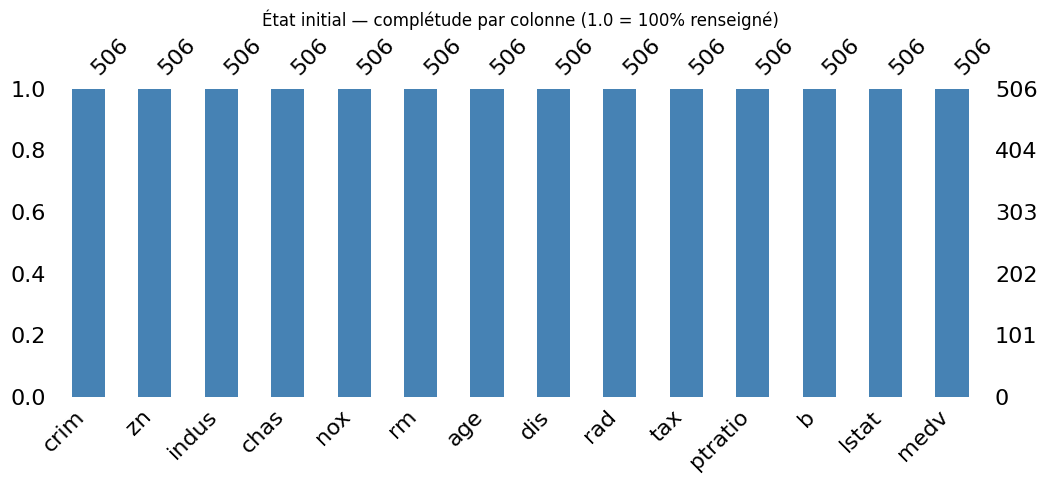

In [92]:
# Visualisation des valeurs manquantes avec missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# msno.bar : un bar chart de la complétude par colonne
# Hauteur de barre = nombre de valeurs présentes (non NaN)
msno.bar(df, figsize=(12, 4), color='steelblue')
plt.title("État initial — complétude par colonne (1.0 = 100% renseigné)")
plt.show()

le dataset Boston est complet (aucun NaN à ce stade)
Les NaN seront créés ensuite par les règles métier et l'IQR pour permettre l'imputation.

### 2.3 Distribution de la variable cible `medv`

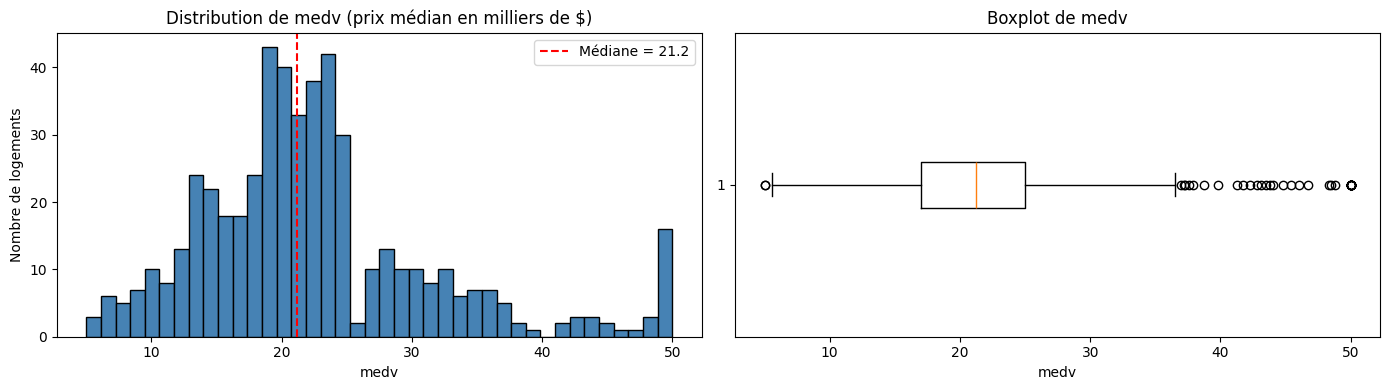

⚠️  Valeurs medv = 50 (potentiellement censurées) : 16 lignes sur 506
Dans le dataset original, les prix > 50 000 $ ont été plafonnés à 50 (artefact connu).
Ces valeurs seront détectées comme outliers par l'IQR et converties en NaN.


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme
axes[0].hist(df['medv'].dropna(), bins=40, edgecolor='black', color='steelblue')
axes[0].axvline(df['medv'].median(), color='red', linestyle='--',
                label=f'Médiane = {df["medv"].median():.1f}')
axes[0].set_title("Distribution de medv (prix médian en milliers de $)")
axes[0].set_xlabel("medv")
axes[0].set_ylabel("Nombre de logements")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['medv'].dropna(), vert=False)
axes[1].set_title("Boxplot de medv")
axes[1].set_xlabel("medv")

plt.tight_layout()
plt.show()

# Détection de la censure à 50
censure = (df['medv'] == 50).sum()
print(f"⚠️  Valeurs medv = 50 (potentiellement censurées) : {censure} lignes sur {len(df)}")
print("Dans le dataset original, les prix > 50 000 $ ont été plafonnés à 50 (artefact connu).")
print("Ces valeurs seront détectées comme outliers par l'IQR et converties en NaN.")

### 2.4 Distributions de toutes les features

On visualise les distributions pour repérer des asymétries, des valeurs extrêmes, des échelles très différentes.

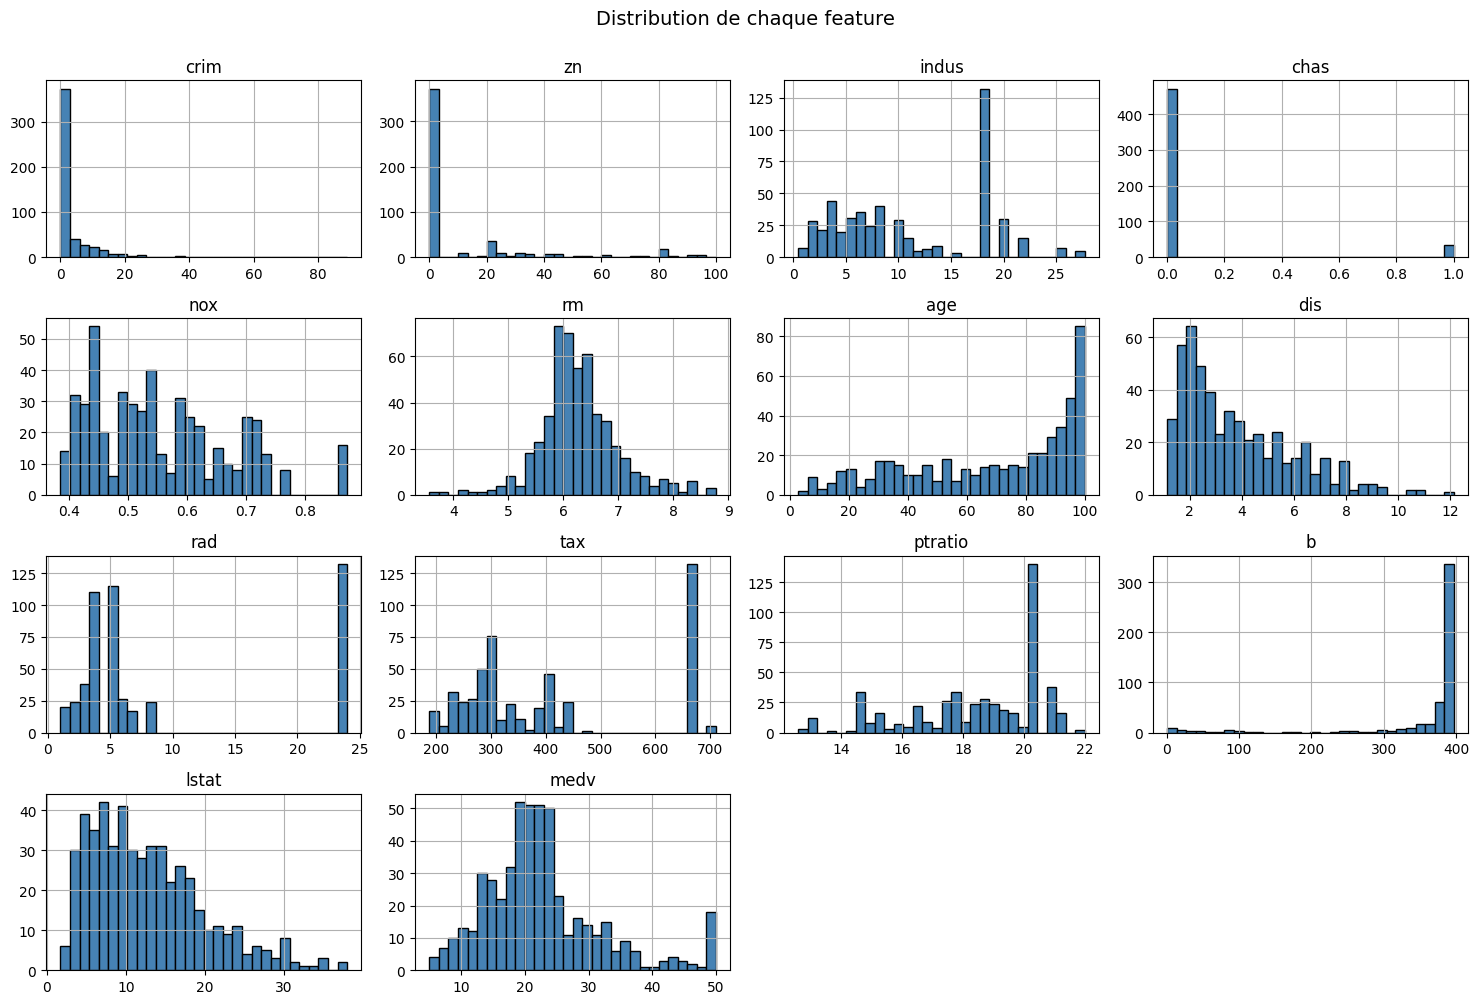

In [94]:
features_num = df.select_dtypes(include='number').columns
df[features_num].hist(bins=30, figsize=(15, 10), edgecolor='black', color='steelblue')
plt.suptitle("Distribution de chaque feature", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 2.5 Matrice de corrélation

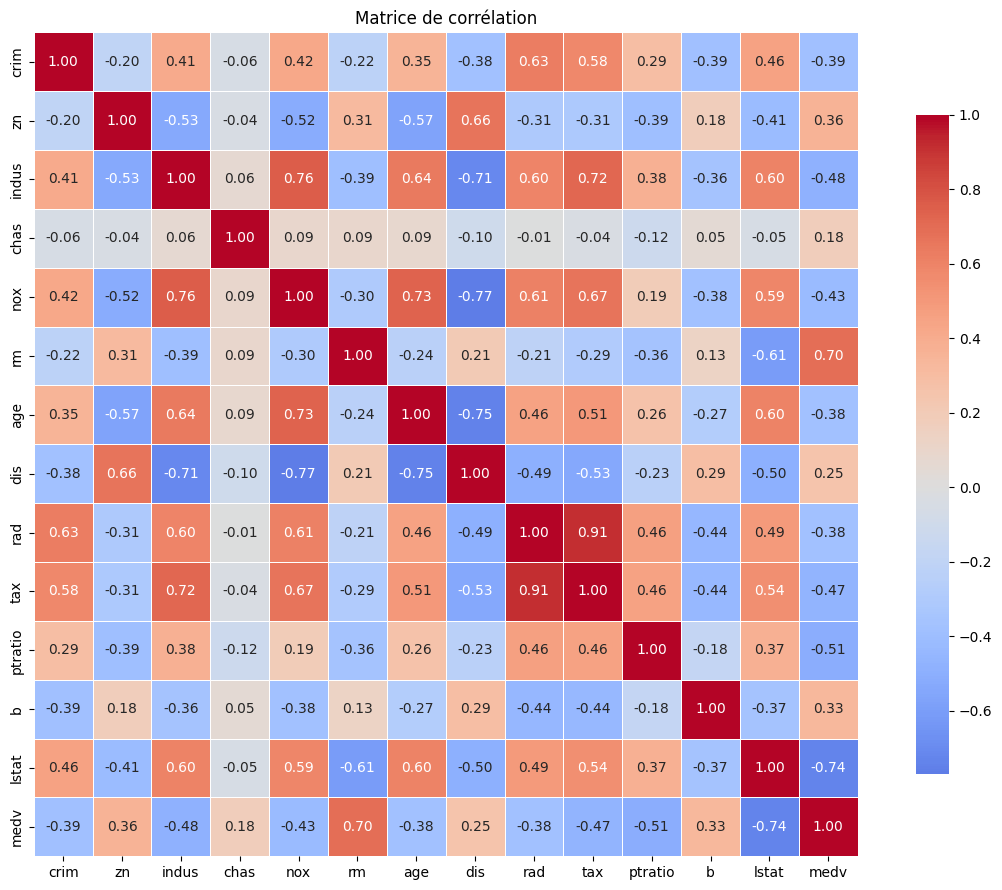

Corrélations avec la cible medv (triées) :
lstat     -0.74
rm         0.70
ptratio   -0.51
indus     -0.48
tax       -0.47
nox       -0.43
crim      -0.39
rad       -0.38
age       -0.38
zn         0.36
b          0.33
dis        0.25
chas       0.18
Name: medv, dtype: float64


In [95]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# Corrélations avec la cible, triées par valeur absolue
corr_target = corr_matrix['medv'].drop('medv').sort_values(key=abs, ascending=False)
print("Corrélations avec la cible medv (triées) :")
print(corr_target.round(2))

**Lecture des corrélations avec `medv`** :
- `lstat` (% de population défavorisée) : forte corrélation négative
- `rm` (nombre moyen de pièces) : forte corrélation positive
- `ptratio` (ratio élèves/professeur) : corrélation négative
- `b` (proportion de population noire dans le quartier) : corrélation faible
- `rad` et `tax` +0.9 : information redondante

## 3. Nettoyage éthique (virer b)

In [96]:
if 'b' in df.columns:
  df = df.drop(columns=['b'])
  print(f"Table size: {df.shape[0]} rows x {df.shape[1]} columns")

Table size: 506 rows x 13 columns


## 4. Suppression des colonnes quasi-vides (50% NaN)

In [97]:
# Seuil de tolérance (50%)
seuil = 0.50
colonnes_a_virer = []

for col in df.columns:
    taux_vide = df[col].isnull().mean()

    if taux_vide > seuil:
        print(f"KO : La colonne '{col}' est vide à {taux_vide*100:.1f}%. Elle va être supprimée.")
        colonnes_a_virer.append(col)
    else:
        print(f"OK : '{col}' est valide ({taux_vide*100:.1f}% de vide).")

# On applique la suppression
df_clean = df.drop(columns=colonnes_a_virer).copy()

OK : 'crim' est valide (0.0% de vide).
OK : 'zn' est valide (0.0% de vide).
OK : 'indus' est valide (0.0% de vide).
OK : 'chas' est valide (0.0% de vide).
OK : 'nox' est valide (0.0% de vide).
OK : 'rm' est valide (0.0% de vide).
OK : 'age' est valide (0.0% de vide).
OK : 'dis' est valide (0.0% de vide).
OK : 'rad' est valide (0.0% de vide).
OK : 'tax' est valide (0.0% de vide).
OK : 'ptratio' est valide (0.0% de vide).
OK : 'lstat' est valide (0.0% de vide).
OK : 'medv' est valide (0.0% de vide).


## 5. Application des règles métier

- les pourcentages entre 0 et 100
- les variables physiquement positives (prix, taux d'imposition, nombre de pièces…) doivent être > 0
- le nombre de pièces (`rm`) doit être entre 1 et 15 (au-delà c'est une erreur)

Toute valeur hors bornes est marquée `NaN` (on l'imputera ensuite avec KNN).

In [98]:
# --- NETTOYAGE MÉTIER ---

# 1. On s'assure que les pourcentages sont entre 0 et 100
cols_pourcentage = ['zn', 'indus', 'age', 'lstat']
for col in cols_pourcentage:
    if col in df_clean.columns:
        # On remplace par NaN ce qui est hors bornes
        df_clean.loc[(df_clean[col] < 0) | (df_clean[col] > 100), col] = np.nan

# 2. On vérifie les valeurs qui doivent être strictement positives
cols_positives = ['crim', 'rm', 'tax', 'ptratio', 'medv']
for col in cols_positives:
    if col in df_clean.columns:
        df_clean.loc[df_clean[col] <= 0, col] = np.nan

# 3. Cas particulier : Le nombre de pièces (RM)
# On peut estimer qu'une moyenne de pièces < 1 ou > 15 est une erreur
if 'rm' in df_clean.columns:
    df_clean.loc[(df_clean['rm'] < 1), 'rm'] = np.nan

print("Nettoyage métier terminé : Les valeurs incohérentes ont été marquées comme manquantes (NaN).")

Nettoyage métier terminé : Les valeurs incohérentes ont été marquées comme manquantes (NaN).


## 6. Bilan du nettoyage déterministe (avant split)

In [99]:
# Bilan intermédiaire avant le split
print("État du dataset après nettoyage déterministe :")
print(f"  Lignes : {len(df_clean)}  (initial : {len(df)})")
print(f"  Colonnes : {df_clean.shape[1]}")
print(f"  NaN actuels (créés par règles métier) : {df_clean.isnull().sum().sum()}")

État du dataset après nettoyage déterministe :
  Lignes : 506  (initial : 506)
  Colonnes : 13
  NaN actuels (créés par règles métier) : 0


## 7. Split train/test

In [100]:
from sklearn.model_selection import train_test_split

# On retire d'abord les lignes où medv est NaN (rien à prédire si la cible manque)
df_clean = df_clean.dropna(subset=['medv'])

X = df_clean.drop(columns=['medv'])
y = df_clean['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 404 lignes
Test  : 102 lignes


## 8. Détection des outliers par IQR (après split)

In [101]:
# IQR appliqué après le split — calcul des seuils sur le TRAIN uniquement
num_cols = [c for c in X_train.select_dtypes(include=['number']).columns if c != 'chas']

# Dictionnaire pour stocker les seuils appris sur le train (utile pour la traçabilité)
seuils_iqr = {}
compteur_outliers_train = 0
compteur_outliers_test = 0

for col in num_cols:
    # ── On apprend Q1, Q3 sur le TRAIN uniquement ──
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_basse = Q1 - 1.5 * IQR
    limite_haute = Q3 + 1.5 * IQR
    seuils_iqr[col] = (limite_basse, limite_haute)

    # ── On applique les MÊMES seuils au train ET au test ──
    mask_train = (X_train[col] < limite_basse) | (X_train[col] > limite_haute)
    mask_test  = (X_test[col] < limite_basse) | (X_test[col] > limite_haute)

    compteur_outliers_train += mask_train.sum()
    compteur_outliers_test += mask_test.sum()

    X_train.loc[mask_train, col] = np.nan
    X_test.loc[mask_test, col] = np.nan

print(f"=== IQR appliqué (seuils appris sur le train) ===")
print(f"  Outliers convertis en NaN — Train : {int(compteur_outliers_train)}")
print(f"  Outliers convertis en NaN — Test  : {int(compteur_outliers_test)}")
print(f"\nSeuils appris (extrait) :")
for col, (lo, hi) in list(seuils_iqr.items())[:5]:
    print(f"  {col:>10} : [{lo:.2f}, {hi:.2f}]")

=== IQR appliqué (seuils appris sur le train) ===
  Outliers convertis en NaN — Train : 131
  Outliers convertis en NaN — Test  : 35

Seuils appris (extrait) :
        crim : [-4.60, 7.89]
          zn : [-30.00, 50.00]
       indus : [-14.33, 37.56]
         nox : [0.18, 0.90]
          rm : [4.77, 7.76]


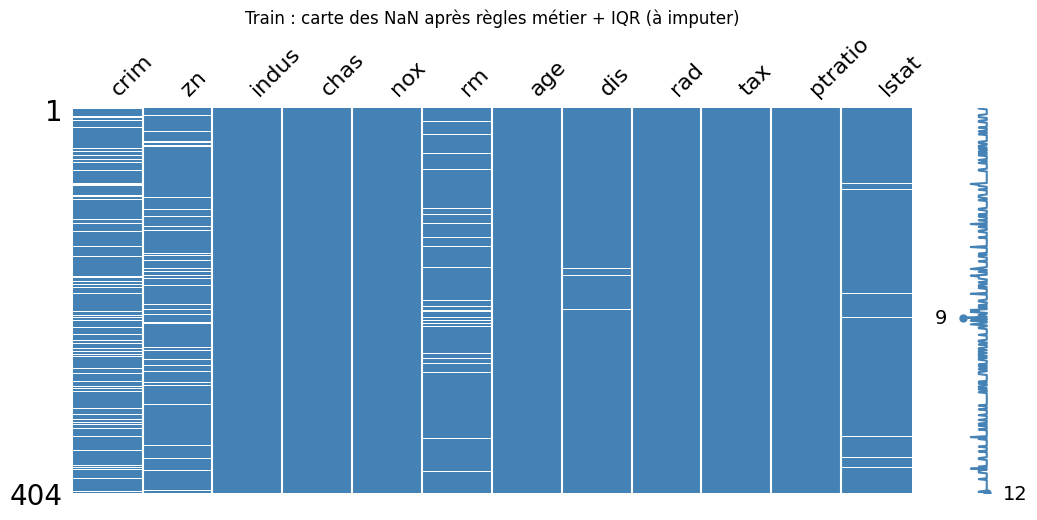

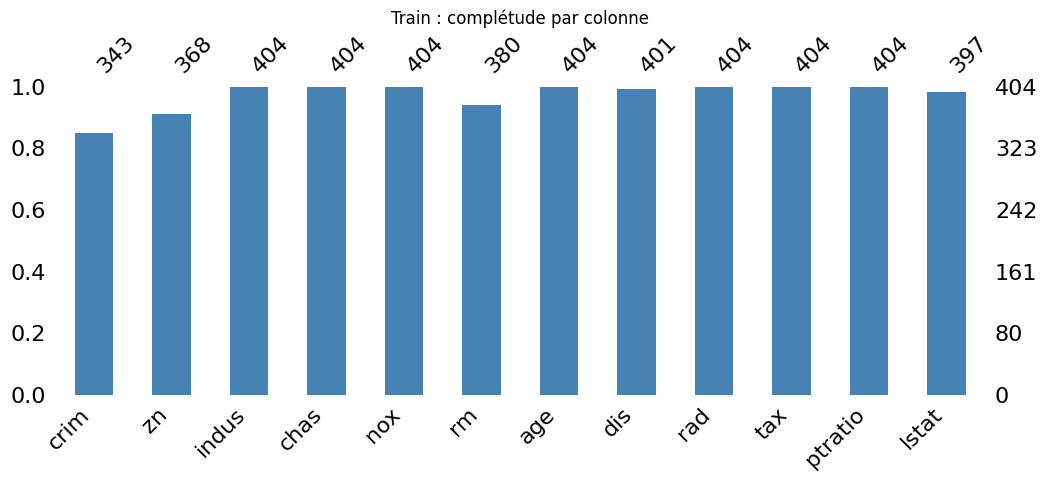

NaN dans le train : 131
NaN dans le test  : 35


In [102]:
# Visualisation des NaN créés par règles métier + IQR (uniquement sur le train)
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(X_train, figsize=(12, 5), color=(0.27, 0.51, 0.71))
plt.title("Train : carte des NaN après règles métier + IQR (à imputer)")
plt.show()

msno.bar(X_train, figsize=(12, 4), color='steelblue')
plt.title("Train : complétude par colonne")
plt.show()

print(f"NaN dans le train : {X_train.isnull().sum().sum()}")
print(f"NaN dans le test  : {X_test.isnull().sum().sum()}")

## 9. Suppression des 2% de lignes les plus incomplètes (sur le train)

In [103]:
# Drop des 2% lignes du train les plus incomplètes (en termes de NaN)
nan_count_train = X_train.isnull().sum(axis=1)
n_max_drop = int(len(X_train) * 0.02)

if (nan_count_train > 0).any() and n_max_drop > 0:
    idx_a_supprimer = nan_count_train.sort_values(ascending=False).head(n_max_drop).index
    X_train = X_train.drop(index=idx_a_supprimer)
    y_train = y_train.drop(index=idx_a_supprimer)
    print(f"Suppression de {len(idx_a_supprimer)} lignes du train (2% les plus dégradées).")
else:
    print("Aucune ligne à supprimer.")

print(f"Train final : {X_train.shape[0]} lignes")
print(f"Test final  : {X_test.shape[0]} lignes (non modifié)")

Suppression de 8 lignes du train (2% les plus dégradées).
Train final : 396 lignes
Test final  : 102 lignes (non modifié)


## 10. Standardisation

**StandardScaler** : transforme chaque colonne pour qu'elle ait moyenne 0 et écart-type 1.
- Indispensable pour la régression linéaire et le KNN (qui utilise des distances).
- Sans effet pour les arbres (Random Forest, LightGBM) mais ne dégrade pas leurs performances.

**fit_transform sur le train, transform sur le test** : la moyenne et l'écart-type sont **appris uniquement sur le train**. Le test est ensuite "scalé" avec ces mêmes paramètres.

`chas` est exclue de la standardisation car c'est une variable binaire (0/1).

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_a_standardiser = [c for c in X_train.columns if c != 'chas']

# fit sur train uniquement, transform sur les deux
X_train[cols_a_standardiser] = scaler.fit_transform(X_train[cols_a_standardiser])
X_test[cols_a_standardiser]  = scaler.transform(X_test[cols_a_standardiser])

print("✓ Standardisation appliquée (fit sur train, transform sur train + test)")

✓ Standardisation appliquée (fit sur train, transform sur train + test)


## 11. Imputation KNN des NaN restants

In [105]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

# fit + transform sur le train
X_train_imputed = imputer.fit_transform(X_train)
# transform sur le test (avec ce qu'il a appris du train)
X_test_imputed  = imputer.transform(X_test)

# Remise en DataFrames (KNNImputer renvoie des arrays numpy)
X_train_final = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_final  = pd.DataFrame(X_test_imputed,  columns=X_test.columns,  index=X_test.index)

print(f"✓ Imputation KNN terminée")
print(f"  NaN restants dans X_train_final : {X_train_final.isnull().sum().sum()}")
print(f"  NaN restants dans X_test_final  : {X_test_final.isnull().sum().sum()}")

✓ Imputation KNN terminée
  NaN restants dans X_train_final : 0
  NaN restants dans X_test_final  : 0


## 12. Modélisation et benchmark des 3 modèles

Régression Linéaire
Random Forest
LightGBM (sur macos : brew install libomp pour eviter l'erreur Library not loaded: @rpath/libomp.dylib)

Pour chaque modèle on calcule **trois métriques** :
- RMSE (Root Mean Squared Error) : erreur en milliers de $. Pénalise fortement les gros écarts.
- MAE (Mean Absolute Error) : erreur moyenne en milliers de $. Moins sensible aux outliers.
- $R^2$ (coefficient de détermination) : % de variance expliquée (1 = parfait, 0 = nul).

In [106]:
# Dictionnaire pour stocker tous les résultats (pour le tableau récap final)
resultats = {}

# Configuration MLflow
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("boston-housing-benchmark")

<Experiment: artifact_location='/Users/sebastien/IA-Expert-IT-Atlas/Module-4/Brief-1/mlruns/3', creation_time=1779095793137, experiment_id='3', last_update_time=1779095793137, lifecycle_stage='active', name='boston-housing-benchmark', tags={}, trace_location=None, workspace='default'>

### 12.1 Régression Linéaire (baseline)

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with mlflow.start_run(run_name="Baseline_Lineaire"):
    model_linear_regression = LinearRegression()
    model_linear_regression.fit(X_train_final, y_train)

    y_pred = model_linear_regression.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model_linear_regression, "model_linear_regression")

    resultats["Régression Linéaire"] = {"RMSE": rmse, "MAE": mae, "R²": r2}

    print(f"✅ Régression Linéaire — RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

2026/05/18 12:03:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 12:03:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Régression Linéaire — RMSE: 4.735 | MAE: 3.108 | R²: 0.694


### 12.2 Random Forest

In [108]:
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name="Random_Forest"):
    model_random_forest_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    model_random_forest_regressor.fit(X_train_final, y_train)

    y_pred = model_random_forest_regressor.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model_random_forest_regressor, "model_random_forest_regressor")

    resultats["Random Forest"] = {"RMSE": rmse, "MAE": mae, "R²": r2}

    print(f"✅ Random Forest — RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

2026/05/18 12:03:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 12:03:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest — RMSE: 3.524 | MAE: 2.384 | R²: 0.831


### 12.3 LightGBM

In [109]:
from lightgbm import LGBMRegressor

with mlflow.start_run(run_name="LightGBM"):
    model_light_GBM_regressor = LGBMRegressor(random_state=42, verbose=-1)
    model_light_GBM_regressor.fit(X_train_final, y_train)

    y_pred = model_light_GBM_regressor.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.lightgbm.log_model(model_light_GBM_regressor, "model_light_GBM_regressor")

    resultats["LightGBM"] = {"RMSE": rmse, "MAE": mae, "R²": r2}

    print(f"✅ LightGBM — RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

2026/05/18 12:03:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 12:03:53 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ LightGBM — RMSE: 3.899 | MAE: 2.559 | R²: 0.793


## 13. Validation croisée (Cross-Validation 5-fold)

In [110]:
from sklearn.model_selection import cross_validate, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# On évalue les 3 modèles via cross-validation sur le train
cv_modeles = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

scoring = {
    "RMSE": "neg_root_mean_squared_error",  # sklearn met "neg" car convention : plus grand = mieux
    "MAE":  "neg_mean_absolute_error",
    "R²":   "r2"
}

resultats_cv = {}
for nom, modele in cv_modeles.items():
    cv_res = cross_validate(modele, X_train_final, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultats_cv[nom] = {
        "RMSE (CV)": -cv_res["test_RMSE"].mean(),
        "RMSE std":   cv_res["test_RMSE"].std(),
        "MAE (CV)":  -cv_res["test_MAE"].mean(),
        "MAE std":    cv_res["test_MAE"].std(),
        "R² (CV)":    cv_res["test_R²"].mean(),
        "R² std":     cv_res["test_R²"].std(),
    }
    print(f"✅ {nom}")
    print(f"   RMSE CV = {-cv_res['test_RMSE'].mean():.3f} ± {cv_res['test_RMSE'].std():.3f}")
    print(f"   MAE  CV = {-cv_res['test_MAE'].mean():.3f} ± {cv_res['test_MAE'].std():.3f}")
    print(f"   R²   CV = {cv_res['test_R²'].mean():.3f} ± {cv_res['test_R²'].std():.3f}")
    print()

✅ Régression Linéaire
   RMSE CV = 5.156 ± 0.771
   MAE  CV = 3.739 ± 0.432
   R²   CV = 0.687 ± 0.071

✅ Random Forest
   RMSE CV = 3.935 ± 0.748
   MAE  CV = 2.660 ± 0.368
   R²   CV = 0.817 ± 0.054

✅ LightGBM
   RMSE CV = 3.929 ± 0.846
   MAE  CV = 2.701 ± 0.466
   R²   CV = 0.817 ± 0.064



## 14. Visualisations et tableau récapitulatif

### 14.1 Visualisations prédictions vs réalité (par modèle)

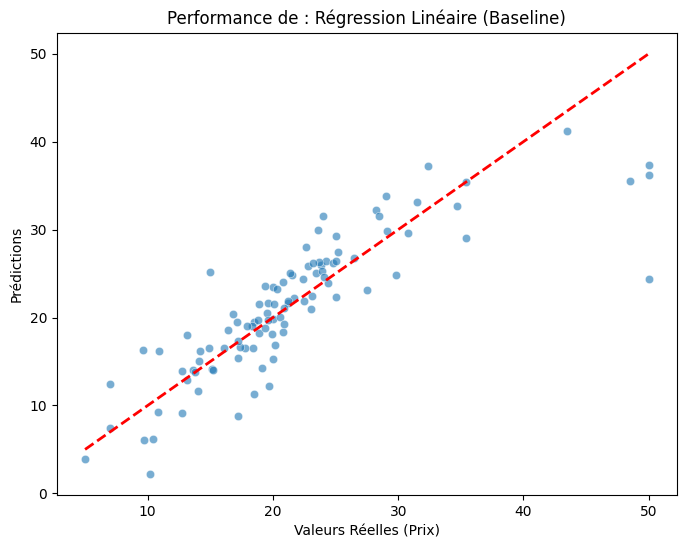

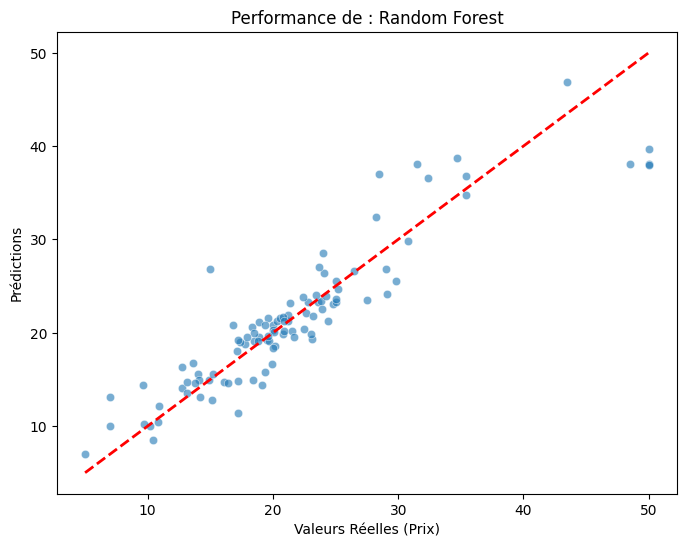

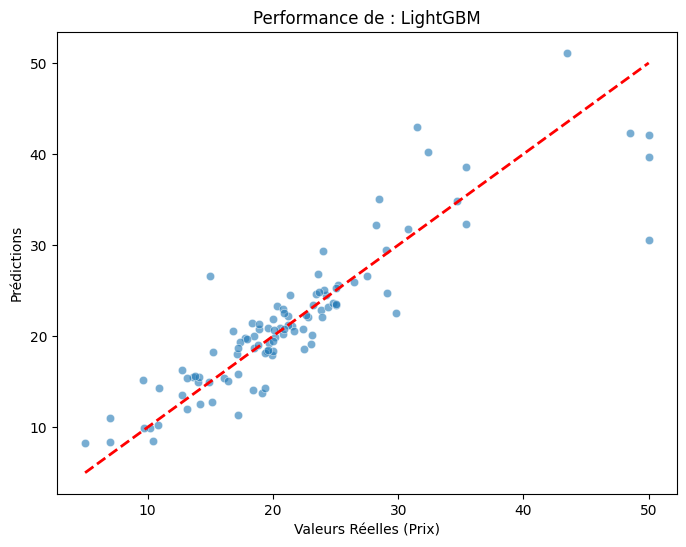

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_regression_results(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    # On trace la ligne de perfection (y = x)
    # Si le point est sur cette ligne, la prédiction est parfaite
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r', lw=2)

    plt.xlabel('Valeurs Réelles (Prix)')
    plt.ylabel('Prédictions')
    plt.title(f'Performance de : {model_name}')
    plt.show()


# 1. Visualisation pour la Régression Linéaire
# On récupère les prédictions (assure-toi que 'model_lin' est ton modèle de régression)
y_pred_lin = model_linear_regression.predict(X_test_final)
plot_regression_results(y_test, y_pred_lin, "Régression Linéaire (Baseline)")

# 2. Visualisation pour le Random Forest
y_pred_rf = model_random_forest_regressor.predict(X_test_final)
plot_regression_results(y_test, y_pred_rf, "Random Forest")

# 3. Visualisation pour le LightGBM
y_pred_lgbm = model_light_GBM_regressor.predict(X_test_final)
plot_regression_results(y_test, y_pred_lgbm, "LightGBM")

### 14.2 Tableau récapitulatif numérique

Comparaison côte à côte des 3 modèles, sur le test set ET en cross-validation.

In [112]:
# Tableau test set
df_resultats_test = pd.DataFrame(resultats).T.round(3)
df_resultats_test.columns = ["RMSE (test)", "MAE (test)", "R² (test)"]

# Tableau cross-validation
df_resultats_cv = pd.DataFrame(resultats_cv).T.round(3)

# Fusion
df_final = pd.concat([df_resultats_test, df_resultats_cv], axis=1)
print("=" * 80)
print("TABLEAU COMPARATIF FINAL — Test set + Cross-Validation 5-fold")
print("=" * 80)
df_final

TABLEAU COMPARATIF FINAL — Test set + Cross-Validation 5-fold


,RMSE (test),MAE (test),R² (test),RMSE (CV),RMSE std,MAE (CV),MAE std,R² (CV),R² std
Régression Linéaire,4.735,3.108,0.694,5.156,0.771,3.739,0.432,0.687,0.071
Random Forest,3.524,2.384,0.831,3.935,0.748,2.660,0.368,0.817,0.054
LightGBM,3.899,2.559,0.793,3.929,0.846,2.701,0.466,0.817,0.064


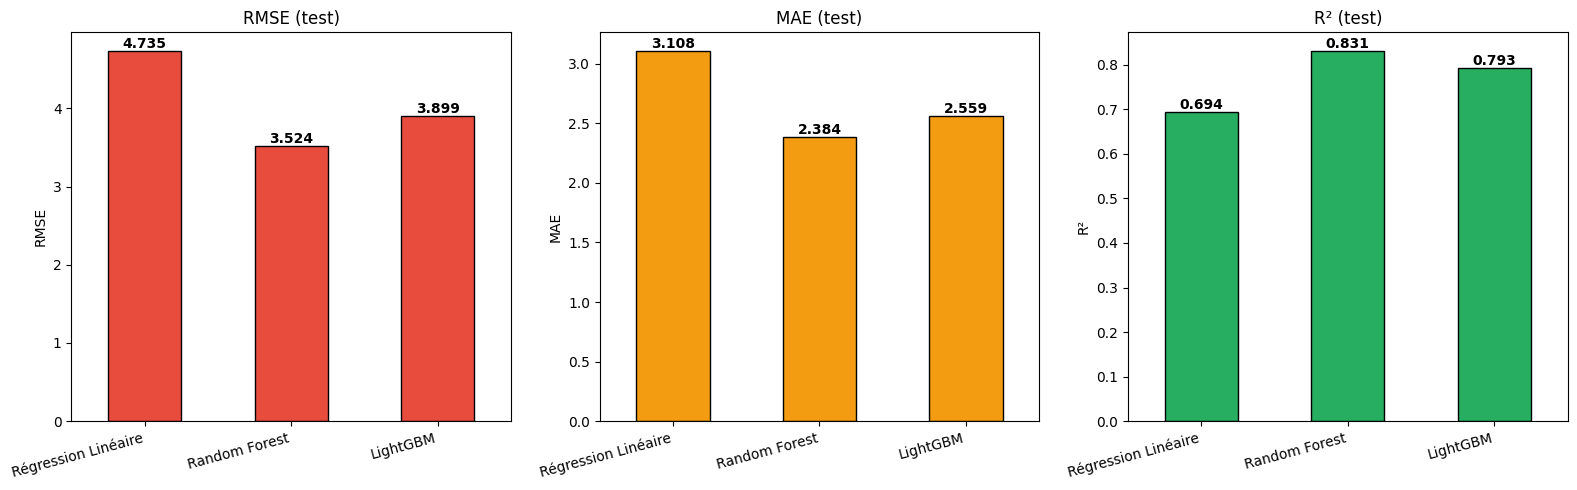

In [113]:
# Visualisation en barres comparatives
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metriques = ["RMSE (test)", "MAE (test)", "R² (test)"]
couleurs = ["#e74c3c", "#f39c12", "#27ae60"]

for ax, metrique, couleur in zip(axes, metriques, couleurs):
    df_resultats_test[metrique].plot(kind='bar', ax=ax, color=couleur, edgecolor='black')
    ax.set_title(metrique)
    ax.set_ylabel(metrique.split()[0])
    ax.set_xticklabels(df_resultats_test.index, rotation=15, ha='right')
    for i, v in enumerate(df_resultats_test[metrique]):
        ax.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Feature importance — quelles variables comptent le plus ?

**Feature importance** = mesure de la contribution de chaque variable aux prédictions du modèle.
- **Régression Linéaire** : ce sont les **coefficients** (positif = pousse le prix vers le haut, négatif = vers le bas)
- **Random Forest et LightGBM** : ce sont les **gains** moyens apportés par chaque split utilisant la variable

Comparer les 3 modèles permet de voir s'ils s'accordent sur ce qui est important.

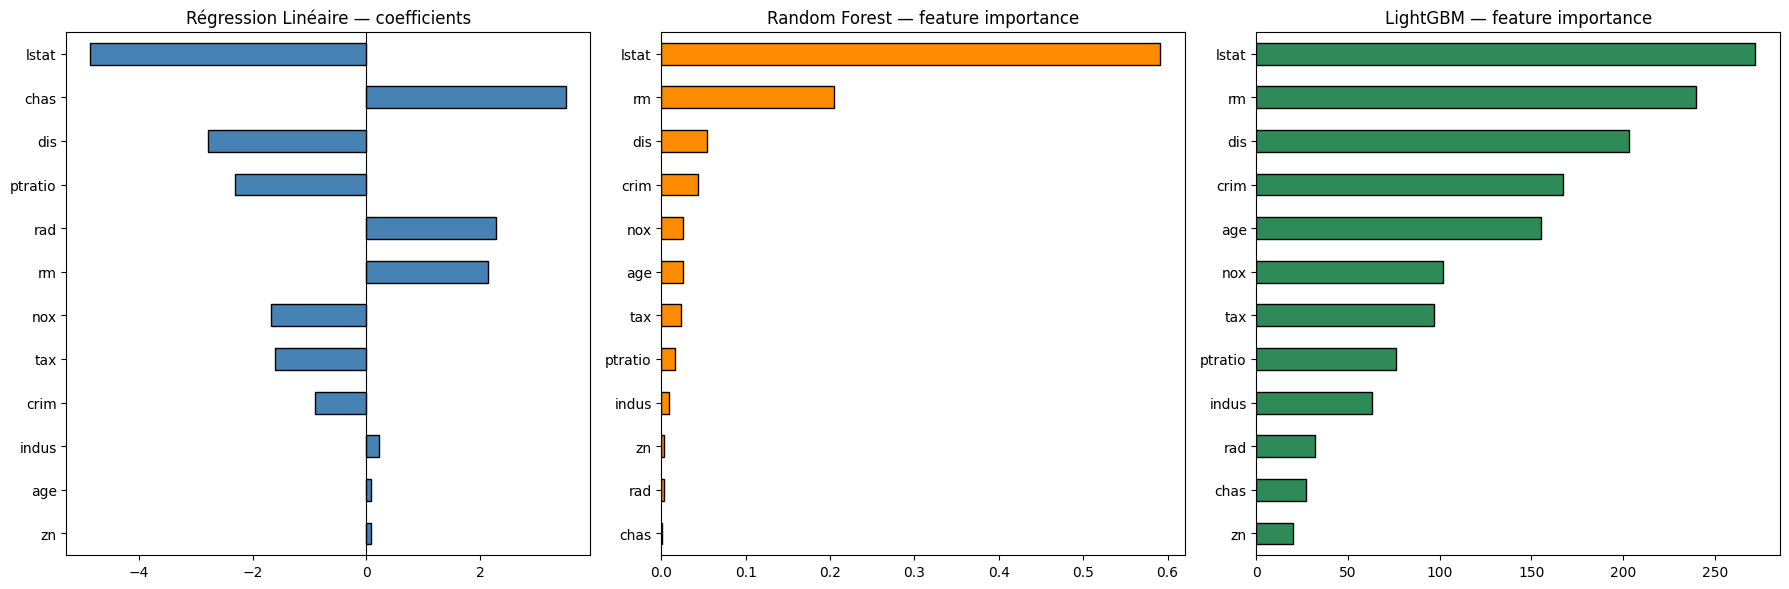

In [114]:
feature_names = X_train_final.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Régression Linéaire : coefficients
coefs = model_linear_regression.coef_
imp_lin = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=True)
imp_lin.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Régression Linéaire — coefficients")
axes[0].axvline(0, color='black', linewidth=0.8)

# Random Forest
imp_rf = pd.Series(model_random_forest_regressor.feature_importances_,
                   index=feature_names).sort_values(ascending=True)
imp_rf.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title("Random Forest — feature importance")

# LightGBM
imp_lgbm = pd.Series(model_light_GBM_regressor.feature_importances_,
                     index=feature_names).sort_values(ascending=True)
imp_lgbm.plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title("LightGBM — feature importance")

plt.tight_layout()
plt.show()

## 16. Conclusion, limites et recommandations

Les 3 mesurent lstat comme la variable la plus importante.

### 16.1 Modèle recommandé

LightGBM en production pour ses performances.